# AEGIS notebook

Project: AEGIS rebuild for reproducible wind anomaly, federated learning, and edge deployment evaluation.


In [1]:
import json
import pickle
import random
import copy
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT        = Path.cwd()
DATA_DIR    = ROOT / "data"
MODELS_DIR  = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
TABLES_DIR  = ROOT / "tables"

WIND_COMBINED_PATH     = DATA_DIR  / "processed" / "02_baseline_combined_dataset.csv"
MAPPING_PATH           = TABLES_DIR / "01_selected_feature_pairs.csv"
VESTAS_PATH            = DATA_DIR  / "Vestas_V52" / "VestasV52_10_min_raw_SCADA_DkIT 30_Jan2006-12_Mar2020.xlsx"
WIND_TRAIN_ERRORS_PATH = RESULTS_DIR / "03_train_normal_reconstruction_errors.csv"

for p in [WIND_COMBINED_PATH, MAPPING_PATH, VESTAS_PATH, WIND_TRAIN_ERRORS_PATH]:
    print(p, "->", p.exists())

C:\Users\MOINODHEEN\Moinu\AEGIS_Project\data\processed\02_baseline_combined_dataset.csv -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\tables\01_selected_feature_pairs.csv -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\data\Vestas_V52\VestasV52_10_min_raw_SCADA_DkIT 30_Jan2006-12_Mar2020.xlsx -> True
C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\03_train_normal_reconstruction_errors.csv -> True


In [2]:
def find_label_column(df):
    for c in df.columns:
        if c.lower() in ["label","anomaly_label","target","y","is_anomaly","class"]:
            return c
    for c in df.columns:
        if "label" in c.lower() or "anomaly" in c.lower():
            return c
    raise ValueError("Label column not found.")

def build_autoencoder(input_dim, bottleneck=4):
    h1 = max(16, input_dim * 2)
    h2 = max(8,  input_dim)
    b  = bottleneck
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(h1, activation="relu"),
        layers.Dense(h2, activation="relu"),
        layers.Dense(b,  activation="relu"),
        layers.Dense(h2, activation="relu"),
        layers.Dense(h1, activation="relu"),
        layers.Dense(input_dim, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def reconstruction_errors(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)

def evaluate_model(name, model, X_test, y_test, threshold):
    scores = reconstruction_errors(model, X_test)
    preds  = (scores > threshold).astype(int)
    cm     = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model":              name,
        "threshold":          float(threshold),
        "precision":          float(precision_score(y_test, preds, zero_division=0)),
        "recall":             float(recall_score(y_test, preds, zero_division=0)),
        "f1":                 float(f1_score(y_test, preds, zero_division=0)),
        "pr_auc":             float(average_precision_score(y_test, scores)),
        "true_negatives":     int(tn),
        "false_positives":    int(fp),
        "false_negatives":    int(fn),
        "true_positives":     int(tp),
        "actual_anomalies":   int(y_test.sum()),
        "predicted_anomalies":int(preds.sum())
    }

def fedavg_weights(weight_list):
    """Average a list of model weight arrays (FedAvg)."""
    avg = []
    for weights_across_clients in zip(*weight_list):
        avg.append(np.mean(weights_across_clients, axis=0))
    return avg

print("Helper functions ready.")

Helper functions ready.


In [3]:
# --- Load Wind Farm A ---
wind_df   = pd.read_csv(WIND_COMBINED_PATH)
label_col = find_label_column(wind_df)

mapping_df = pd.read_csv(MAPPING_PATH)
mapping_df.columns = ["wind_feature", "vestas_feature"]
mapping_df["wind_feature"]   = mapping_df["wind_feature"].astype(str).str.strip()
mapping_df["vestas_feature"] = mapping_df["vestas_feature"].astype(str).str.strip()

wind_features_mapped   = mapping_df["wind_feature"].tolist()
vestas_features_mapped = mapping_df["vestas_feature"].tolist()

# Wind Farm A: use only mapped features, keep labels
wind_mapped = wind_df[wind_features_mapped + [label_col]].dropna().copy()
X_wind_all  = wind_mapped[wind_features_mapped].values
y_wind_all  = wind_mapped[label_col].values

# Split Wind Farm A: train (normal only for AE training), test (mixed)
X_wind_train_idx = np.where(y_wind_all == 0)[0]
X_wind_test_idx  = np.arange(len(y_wind_all))

# Use 80% of normals for training, rest goes to test pool
split = int(len(X_wind_train_idx) * 0.8)
train_idx = X_wind_train_idx[:split]
test_idx  = np.concatenate([X_wind_train_idx[split:], np.where(y_wind_all == 1)[0]])

X_wind_train_raw = X_wind_all[train_idx]
X_wind_test_raw  = X_wind_all[test_idx]
y_wind_test      = y_wind_all[test_idx]

wind_scaler   = StandardScaler()
X_wind_train  = wind_scaler.fit_transform(X_wind_train_raw)
X_wind_test   = wind_scaler.transform(X_wind_test_raw)

# --- Load Vestas ---
vestas_df      = pd.read_excel(VESTAS_PATH)
numeric_vestas = vestas_df.select_dtypes(include=[np.number]).copy()
numeric_vestas = numeric_vestas.fillna(numeric_vestas.median(numeric_only=True))

power_col  = [c for c in numeric_vestas.columns if "power" in c.lower()][0]
power_data = numeric_vestas[power_col]
z_scores   = np.abs((power_data - power_data.mean()) / power_data.std())
y_vestas_all = (z_scores > 2.5).astype(int).values

# Vestas: rename mapped features to wind names
vestas_mapped_raw           = numeric_vestas[vestas_features_mapped].copy()
vestas_mapped_raw.columns   = wind_features_mapped
X_vestas_all = vestas_mapped_raw.values

# Split Vestas similarly
vestas_normal_idx = np.where(y_vestas_all == 0)[0]
v_split           = int(len(vestas_normal_idx) * 0.8)
vestas_train_idx  = vestas_normal_idx[:v_split]
vestas_test_idx   = np.concatenate([vestas_normal_idx[v_split:], np.where(y_vestas_all == 1)[0]])

X_vestas_train_raw = X_vestas_all[vestas_train_idx]
X_vestas_test_raw  = X_vestas_all[vestas_test_idx]
y_vestas_test      = y_vestas_all[vestas_test_idx]

vestas_scaler   = StandardScaler()
X_vestas_train  = vestas_scaler.fit_transform(X_vestas_train_raw)
X_vestas_test   = vestas_scaler.transform(X_vestas_test_raw)

INPUT_DIM = len(wind_features_mapped)

print(f"Input dim (shared features): {INPUT_DIM}")
print(f"Wind train shape:   {X_wind_train.shape}")
print(f"Wind test shape:    {X_wind_test.shape}  | anomalies: {int(y_wind_test.sum())}")
print(f"Vestas train shape: {X_vestas_train.shape}")
print(f"Vestas test shape:  {X_vestas_test.shape} | anomalies: {int(y_vestas_test.sum())}")

Input dim (shared features): 6
Wind train shape:   (87620, 6)
Wind test shape:    (129299, 6)  | anomalies: 107394
Vestas train shape: (501922, 6)
Vestas test shape:  (151181, 6) | anomalies: 25700


In [4]:
print("Training LOCAL Wind Farm A model...")
local_wind_model = build_autoencoder(INPUT_DIM, bottleneck=4)
local_wind_model.fit(
    X_wind_train, X_wind_train,
    validation_split=0.1,
    epochs=40, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)
wind_train_scores    = reconstruction_errors(local_wind_model, X_wind_train)
wind_local_threshold = np.percentile(wind_train_scores, 95)
print(f"  Wind local threshold (95th pct): {wind_local_threshold:.6f}")

print("\nTraining LOCAL Vestas model...")
local_vestas_model = build_autoencoder(INPUT_DIM, bottleneck=4)
local_vestas_model.fit(
    X_vestas_train, X_vestas_train,
    validation_split=0.1,
    epochs=40, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)
vestas_train_scores    = reconstruction_errors(local_vestas_model, X_vestas_train)
vestas_local_threshold = np.percentile(vestas_train_scores, 95)
print(f"  Vestas local threshold (95th pct): {vestas_local_threshold:.6f}")

# Evaluate both local models on both test sets
local_wind_on_wind     = evaluate_model("Local-Wind → Wind test",   local_wind_model,   X_wind_test,   y_wind_test,   wind_local_threshold)
local_wind_on_vestas   = evaluate_model("Local-Wind → Vestas test", local_wind_model,   X_vestas_test, y_vestas_test, wind_local_threshold)
local_vestas_on_vestas = evaluate_model("Local-Vestas → Vestas test", local_vestas_model, X_vestas_test, y_vestas_test, vestas_local_threshold)
local_vestas_on_wind   = evaluate_model("Local-Vestas → Wind test", local_vestas_model, X_wind_test,   y_wind_test,   vestas_local_threshold)

local_results = pd.DataFrame([local_wind_on_wind, local_vestas_on_vestas,
                               local_wind_on_vestas, local_vestas_on_wind])
display(local_results[["model","precision","recall","f1","pr_auc"]])
print("Local baselines done.")

Training LOCAL Wind Farm A model...
  Wind local threshold (95th pct): 0.008305

Training LOCAL Vestas model...
  Vestas local threshold (95th pct): 0.018869


,model,precision,recall,f1,pr_auc
0,Local-Wind → Wind test,0.839408,0.05383,0.101172,0.835369
1,Local-Vestas → Vestas test,0.818636,0.82214,0.820384,0.898143
2,Local-Wind → Vestas test,0.274321,1.00000,0.430536,0.981409
3,Local-Vestas → Wind test,0.831967,0.49229,0.618564,0.834259


Local baselines done.


In [11]:
local_wind_model.save(MODELS_DIR / "06_local_wind_model.keras")
print("Saved local wind model.")

Saved local wind model.


In [5]:
FL_ROUNDS  = 10
FL_EPOCHS  = 3      # local epochs per round
FL_BATCH   = 256

# Initialise global model
global_model = build_autoencoder(INPUT_DIM, bottleneck=4)

round_log = []

print(f"Starting FedAvg — {FL_ROUNDS} rounds, {FL_EPOCHS} local epochs each\n")

for rnd in range(1, FL_ROUNDS + 1):
    global_weights = global_model.get_weights()

    # --- Client 1: Wind Farm A ---
    client_wind = build_autoencoder(INPUT_DIM, bottleneck=4)
    client_wind.set_weights(copy.deepcopy(global_weights))
    client_wind.fit(X_wind_train, X_wind_train,
                    epochs=FL_EPOCHS, batch_size=FL_BATCH, verbose=0)

    # --- Client 2: Vestas ---
    client_vestas = build_autoencoder(INPUT_DIM, bottleneck=4)
    client_vestas.set_weights(copy.deepcopy(global_weights))
    client_vestas.fit(X_vestas_train, X_vestas_train,
                      epochs=FL_EPOCHS, batch_size=FL_BATCH, verbose=0)

    # --- FedAvg aggregation ---
    new_weights = fedavg_weights([
        client_wind.get_weights(),
        client_vestas.get_weights()
    ])
    global_model.set_weights(new_weights)

    # --- Evaluate global model this round ---
    wind_err_rnd   = reconstruction_errors(global_model, X_wind_train)
    vestas_err_rnd = reconstruction_errors(global_model, X_vestas_train)

    thr_wind_rnd   = np.percentile(wind_err_rnd,   95)
    thr_vestas_rnd = np.percentile(vestas_err_rnd, 95)

    wind_preds_rnd   = (reconstruction_errors(global_model, X_wind_test)   > thr_wind_rnd).astype(int)
    vestas_preds_rnd = (reconstruction_errors(global_model, X_vestas_test) > thr_vestas_rnd).astype(int)

    wind_f1_rnd   = f1_score(y_wind_test,   wind_preds_rnd,   zero_division=0)
    vestas_f1_rnd = f1_score(y_vestas_test, vestas_preds_rnd, zero_division=0)

    wind_loss_rnd   = float(np.mean(wind_err_rnd))
    vestas_loss_rnd = float(np.mean(vestas_err_rnd))

    round_log.append({
        "round":               rnd,
        "wind_train_loss":     wind_loss_rnd,
        "vestas_train_loss":   vestas_loss_rnd,
        "wind_test_f1":        wind_f1_rnd,
        "vestas_test_f1":      vestas_f1_rnd
    })

    print(f"Round {rnd:2d} | "
          f"Wind loss: {wind_loss_rnd:.5f}  F1: {wind_f1_rnd:.4f} | "
          f"Vestas loss: {vestas_loss_rnd:.5f}  F1: {vestas_f1_rnd:.4f}")

round_df = pd.DataFrame(round_log)
rounds_csv = RESULTS_DIR / "06_federated_round_metrics.csv"
round_df.to_csv(rounds_csv, index=False)
print(f"\nSaved: {rounds_csv}")
display(round_df)

Starting FedAvg — 10 rounds, 3 local epochs each

Round  1 | Wind loss: 0.32411  F1: 0.0907 | Vestas loss: 0.28803  F1: 0.5843
Round  2 | Wind loss: 0.08441  F1: 0.1040 | Vestas loss: 0.09420  F1: 0.3700
Round  3 | Wind loss: 0.06405  F1: 0.1022 | Vestas loss: 0.05329  F1: 0.3829
Round  4 | Wind loss: 0.03134  F1: 0.0942 | Vestas loss: 0.03271  F1: 0.8164
Round  5 | Wind loss: 0.02867  F1: 0.0781 | Vestas loss: 0.02730  F1: 0.7910
Round  6 | Wind loss: 0.02100  F1: 0.0822 | Vestas loss: 0.02508  F1: 0.8595
Round  7 | Wind loss: 0.01477  F1: 0.0904 | Vestas loss: 0.01704  F1: 0.8829
Round  8 | Wind loss: 0.01087  F1: 0.1123 | Vestas loss: 0.01070  F1: 0.5214
Round  9 | Wind loss: 0.00986  F1: 0.1128 | Vestas loss: 0.00934  F1: 0.4561
Round 10 | Wind loss: 0.00997  F1: 0.1131 | Vestas loss: 0.00889  F1: 0.4804

Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\06_federated_round_metrics.csv


,round,wind_train_loss,vestas_train_loss,wind_test_f1,vestas_test_f1
0,1,0.324106,0.288027,0.090668,0.584300
1,2,0.084409,0.094201,0.104000,0.369993
2,3,0.064053,0.053285,0.102158,0.382860
3,4,0.031342,0.032710,0.094154,0.816445
4,5,0.028669,0.027305,0.078092,0.791027
5,6,0.021002,0.025082,0.082188,0.859533
6,7,0.014772,0.017040,0.090407,0.882866
7,8,0.010873,0.010697,0.112324,0.521383
8,9,0.009855,0.009343,0.112811,0.456070
9,10,0.009974,0.008890,0.113086,0.480380


In [6]:
# Final thresholds from last round training errors
fl_wind_train_errors   = reconstruction_errors(global_model, X_wind_train)
fl_vestas_train_errors = reconstruction_errors(global_model, X_vestas_train)

fl_wind_threshold   = np.percentile(fl_wind_train_errors,   95)
fl_vestas_threshold = np.percentile(fl_vestas_train_errors, 95)

fedavg_on_wind   = evaluate_model("FedAvg global → Wind test",   global_model, X_wind_test,   y_wind_test,   fl_wind_threshold)
fedavg_on_vestas = evaluate_model("FedAvg global → Vestas test", global_model, X_vestas_test, y_vestas_test, fl_vestas_threshold)

# Build full comparison table
all_results = pd.DataFrame([
    local_wind_on_wind,
    local_vestas_on_vestas,
    local_wind_on_vestas,
    fedavg_on_wind,
    fedavg_on_vestas
])

results_csv = RESULTS_DIR / "06_federated_final_results.csv"
tables_csv  = TABLES_DIR  / "06_federated_final_results.csv"
all_results.to_csv(results_csv, index=False)
all_results.to_csv(tables_csv,  index=False)

display(all_results[["model","precision","recall","f1","pr_auc","false_positives","false_negatives"]])
print(f"\nSaved: {results_csv}")
print(f"Saved: {tables_csv}")

# Save global model
global_model.save(MODELS_DIR / "06_fedavg_global_model.keras")

with open(MODELS_DIR / "06_fedavg_wind_scaler.pkl",   "wb") as f: pickle.dump(wind_scaler, f)
with open(MODELS_DIR / "06_fedavg_vestas_scaler.pkl", "wb") as f: pickle.dump(vestas_scaler, f)

print("Saved: 06_fedavg_global_model.keras")

,model,precision,recall,f1,pr_auc,false_positives,false_negatives
0,Local-Wind → Wind test,0.839408,0.053830,0.101172,0.835369,1106,101613
1,Local-Vestas → Vestas test,0.818636,0.822140,0.820384,0.898143,4681,4571
2,Local-Wind → Vestas test,0.274321,1.000000,0.430536,0.981409,67986,0
3,FedAvg global → Wind test,0.851978,0.060562,0.113086,0.841544,1130,100890
4,FedAvg global → Vestas test,0.704665,0.364397,0.480380,0.661426,3925,16335



Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\results\06_federated_final_results.csv
Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\tables\06_federated_final_results.csv
Saved: 06_fedavg_global_model.keras


In [7]:
# Count trainable parameters exchanged per round
total_params = sum(np.prod(w.shape) for w in global_model.get_weights())
params_bytes  = total_params * 4   # float32
params_kb     = params_bytes / 1024

comm_stats = {
    "fl_rounds":                  FL_ROUNDS,
    "local_epochs_per_round":     FL_EPOCHS,
    "num_clients":                2,
    "trainable_parameters":       int(total_params),
    "bytes_per_upload_float32":   int(params_bytes),
    "kb_per_upload_float32":      round(params_kb, 3),
    "total_uploads":              FL_ROUNDS * 2,
    "total_kb_communicated":      round(params_kb * FL_ROUNDS * 2, 3)
}

comm_df = pd.DataFrame([comm_stats])
comm_df.to_csv(RESULTS_DIR / "06_communication_stats.csv", index=False)
comm_df.to_csv(TABLES_DIR  / "06_communication_stats.csv", index=False)

display(comm_df)
print("Saved communication stats.")

,fl_rounds,local_epochs_per_round,num_clients,trainable_parameters,bytes_per_upload_float32,kb_per_upload_float32,total_uploads,total_kb_communicated
0,10,3,2,570,2280,2.227,20,44.531


Saved communication stats.


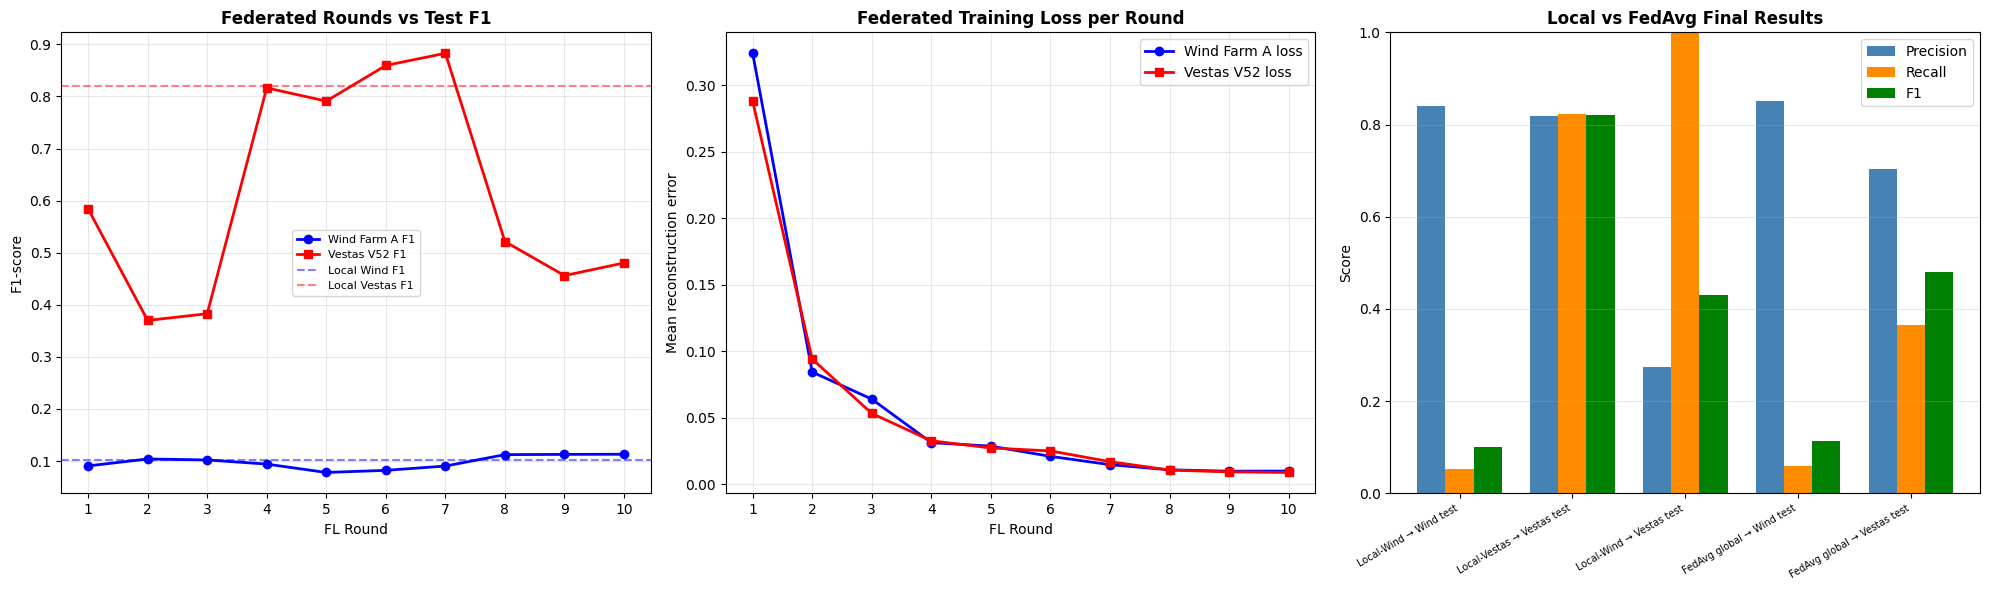

Saved: C:\Users\MOINODHEEN\Moinu\AEGIS_Project\figures\06_federated_rounds_vs_f1.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: FL rounds vs F1 on both sites ---
ax = axes[0]
ax.plot(round_df["round"], round_df["wind_test_f1"],   "b-o", label="Wind Farm A F1",  linewidth=2)
ax.plot(round_df["round"], round_df["vestas_test_f1"], "r-s", label="Vestas V52 F1",   linewidth=2)
ax.axhline(local_wind_on_wind["f1"],     color="blue",  linestyle="--", alpha=0.5, label="Local Wind F1")
ax.axhline(local_vestas_on_vestas["f1"], color="red",   linestyle="--", alpha=0.5, label="Local Vestas F1")
ax.set_xlabel("FL Round")
ax.set_ylabel("F1-score")
ax.set_title("Federated Rounds vs Test F1", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, FL_ROUNDS + 1))

# --- Plot 2: FL rounds vs training loss ---
ax = axes[1]
ax.plot(round_df["round"], round_df["wind_train_loss"],   "b-o", label="Wind Farm A loss",  linewidth=2)
ax.plot(round_df["round"], round_df["vestas_train_loss"], "r-s", label="Vestas V52 loss",   linewidth=2)
ax.set_xlabel("FL Round")
ax.set_ylabel("Mean reconstruction error")
ax.set_title("Federated Training Loss per Round", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, FL_ROUNDS + 1))

# --- Plot 3: final comparison bar chart ---
ax = axes[2]
compare_rows = all_results[all_results["model"].isin([
    "Local-Wind → Wind test",
    "Local-Vestas → Vestas test",
    "Local-Wind → Vestas test",
    "FedAvg global → Wind test",
    "FedAvg global → Vestas test"
])].copy()

x = np.arange(len(compare_rows))
w = 0.25
ax.bar(x - w,   compare_rows["precision"], w, label="Precision", color="steelblue")
ax.bar(x,       compare_rows["recall"],    w, label="Recall",    color="darkorange")
ax.bar(x + w,   compare_rows["f1"],        w, label="F1",        color="green")
ax.set_xticks(x)
ax.set_xticklabels(compare_rows["model"], rotation=30, ha="right", fontsize=7)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Local vs FedAvg Final Results", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig_path = FIGURES_DIR / "06_federated_rounds_vs_f1.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

In [10]:
best_fed_wind   = fedavg_on_wind
best_fed_vestas = fedavg_on_vestas

lines = [
    "Federated Learning Summary",
    "==========================",
    "",
    f"FL rounds:                {FL_ROUNDS}",
    f"Local epochs per round:   {FL_EPOCHS}",
    f"Clients:                  2 (Wind Farm A, Vestas V52)",
    f"Shared features:          {INPUT_DIM}",
    f"Parameters per model:     {int(total_params):,}",
    f"KB communicated total:    {comm_stats['total_kb_communicated']:.1f} KB",
    "",
    "--- Local baselines ---",
    f"Local Wind → Wind:         P={local_wind_on_wind['precision']:.4f}  R={local_wind_on_wind['recall']:.4f}  F1={local_wind_on_wind['f1']:.4f}  PR-AUC={local_wind_on_wind['pr_auc']:.4f}",
    f"Local Vestas → Vestas:     P={local_vestas_on_vestas['precision']:.4f}  R={local_vestas_on_vestas['recall']:.4f}  F1={local_vestas_on_vestas['f1']:.4f}  PR-AUC={local_vestas_on_vestas['pr_auc']:.4f}",
    f"Local Wind → Vestas:       P={local_wind_on_vestas['precision']:.4f}  R={local_wind_on_vestas['recall']:.4f}  F1={local_wind_on_vestas['f1']:.4f}  PR-AUC={local_wind_on_vestas['pr_auc']:.4f}",
    "",
    "--- FedAvg global model ---",
    f"FedAvg → Wind test:        P={best_fed_wind['precision']:.4f}  R={best_fed_wind['recall']:.4f}  F1={best_fed_wind['f1']:.4f}  PR-AUC={best_fed_wind['pr_auc']:.4f}",
    f"FedAvg → Vestas test:      P={best_fed_vestas['precision']:.4f}  R={best_fed_vestas['recall']:.4f}  F1={best_fed_vestas['f1']:.4f}  PR-AUC={best_fed_vestas['pr_auc']:.4f}",
]

txt = "\n".join(lines)
with open(RESULTS_DIR / "06_federated_summary.txt", "w", encoding="utf-8") as f: f.write(txt)
with open(RESULTS_DIR / "06_federated_summary.md",  "w", encoding="utf-8") as f: f.write(txt)

print(txt)
print("\nSaved: 06_federated_summary.txt")
print("Saved: 06_federated_summary.md")

Federated Learning Summary

FL rounds:                10
Local epochs per round:   3
Clients:                  2 (Wind Farm A, Vestas V52)
Shared features:          6
Parameters per model:     570
KB communicated total:    44.5 KB

--- Local baselines ---
Local Wind → Wind:         P=0.8394  R=0.0538  F1=0.1012  PR-AUC=0.8354
Local Vestas → Vestas:     P=0.8186  R=0.8221  F1=0.8204  PR-AUC=0.8981
Local Wind → Vestas:       P=0.2743  R=1.0000  F1=0.4305  PR-AUC=0.9814

--- FedAvg global model ---
FedAvg → Wind test:        P=0.8520  R=0.0606  F1=0.1131  PR-AUC=0.8415
FedAvg → Vestas test:      P=0.7047  R=0.3644  F1=0.4804  PR-AUC=0.6614

Saved: 06_federated_summary.txt
Saved: 06_federated_summary.md


In [14]:
candidate_names = [k for k in globals().keys() if any(
    token in k.lower() for token in [
        "model", "global", "fed", "node", "x_test", "y_test", "test", "wind", "vestas", "threshold"
    ]
)]
for name in sorted(candidate_names):
    try:
        obj = globals()[name]
        shape = getattr(obj, "shape", None)
        print(f"{name:35s} | type={type(obj).__name__} | shape={shape}")
    except Exception:
        print(f"{name:35s} | type={type(globals()[name]).__name__}")

MODELS_DIR                          | type=WindowsPath | shape=None
VESTAS_PATH                         | type=WindowsPath | shape=None
WIND_COMBINED_PATH                  | type=WindowsPath | shape=None
WIND_TRAIN_ERRORS_PATH              | type=WindowsPath | shape=None
X_vestas                            | type=NoneType | shape=None
X_vestas_all                        | type=ndarray | shape=(653103, 6)
X_vestas_name                       | type=NoneType | shape=None
X_vestas_test                       | type=ndarray | shape=(151181, 6)
X_vestas_test_raw                   | type=ndarray | shape=(151181, 6)
X_vestas_train                      | type=ndarray | shape=(501922, 6)
X_vestas_train_raw                  | type=ndarray | shape=(501922, 6)
X_wind_all                          | type=ndarray | shape=(216919, 6)
X_wind_test                         | type=ndarray | shape=(129299, 6)
X_wind_test_idx                     | type=ndarray | shape=(216919,)
X_wind_test_raw                 

In [15]:
import os
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

os.makedirs("results", exist_ok=True)
os.makedirs("tables", exist_ok=True)

def eval_global(model, X_test, y_test, threshold, site_name):
    recon = model.predict(X_test, verbose=0)
    err = ((X_test - recon) ** 2).mean(axis=1)
    preds = (err > threshold).astype(int)
    cm = confusion_matrix(y_test, preds)

    return {
        "site": site_name,
        "model": "FedAvg Global",
        "threshold": float(threshold),
        "test_samples": int(len(y_test)),
        "precision": float(precision_score(y_test, preds, zero_division=0)),
        "recall": float(recall_score(y_test, preds, zero_division=0)),
        "f1": float(f1_score(y_test, preds, zero_division=0)),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
        "predicted_anomalies": int(preds.sum())
    }

fed_wind_metrics = eval_global(global_model, X_wind_test, y_wind_test, fl_wind_threshold, "Wind Farm A")
fed_vestas_metrics = eval_global(global_model, X_vestas_test, y_vestas_test, fl_vestas_threshold, "Vestas V52")

fed_df = pd.DataFrame([fed_wind_metrics, fed_vestas_metrics])
fed_df.to_csv("results/06_federated_test_metrics.csv", index=False)

fed_df

,site,model,threshold,test_samples,precision,recall,f1,tn,fp,fn,tp,predicted_anomalies
0,Wind Farm A,FedAvg Global,0.046078,129299,0.851978,0.060562,0.113086,20775,1130,100890,6504,7634
1,Vestas V52,FedAvg Global,0.028912,151181,0.704665,0.364397,0.480380,121556,3925,16335,9365,13290


In [16]:
import pandas as pd
import os

def pick_metric(d, key_options):
    for k in key_options:
        if k in d:
            return d[k]
    return None

comparison_rows = [
    {
        "site": "Wind Farm A",
        "model": "Local Wind Model",
        "precision": pick_metric(local_wind_on_wind, ["precision"]),
        "recall": pick_metric(local_wind_on_wind, ["recall"]),
        "f1": pick_metric(local_wind_on_wind, ["f1", "f1_score", "f1score"])
    },
    {
        "site": "Wind Farm A",
        "model": "FedAvg Global",
        "precision": fed_wind_metrics["precision"],
        "recall": fed_wind_metrics["recall"],
        "f1": fed_wind_metrics["f1"]
    },
    {
        "site": "Vestas V52",
        "model": "Local Vestas Model",
        "precision": pick_metric(local_vestas_on_vestas, ["precision"]),
        "recall": pick_metric(local_vestas_on_vestas, ["recall"]),
        "f1": pick_metric(local_vestas_on_vestas, ["f1", "f1_score", "f1score"])
    },
    {
        "site": "Vestas V52",
        "model": "FedAvg Global",
        "precision": fed_vestas_metrics["precision"],
        "recall": fed_vestas_metrics["recall"],
        "f1": fed_vestas_metrics["f1"]
    }
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("tables/06_federated_model_comparison.csv", index=False)

comparison_df

,site,model,precision,recall,f1
0,Wind Farm A,Local Wind Model,0.839408,0.053830,0.101172
1,Wind Farm A,FedAvg Global,0.851978,0.060562,0.113086
2,Vestas V52,Local Vestas Model,0.818636,0.822140,0.820384
3,Vestas V52,FedAvg Global,0.704665,0.364397,0.480380


In [17]:
import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

delta_rows = [
    {
        "site": "Wind Farm A",
        "local_model": "Local Wind Model",
        "federated_model": "FedAvg Global",
        "precision_delta": fed_wind_metrics["precision"] - local_wind_on_wind["precision"],
        "recall_delta": fed_wind_metrics["recall"] - local_wind_on_wind["recall"],
        "f1_delta": fed_wind_metrics["f1"] - local_wind_on_wind["f1"]
    },
    {
        "site": "Vestas V52",
        "local_model": "Local Vestas Model",
        "federated_model": "FedAvg Global",
        "precision_delta": fed_vestas_metrics["precision"] - local_vestas_on_vestas["precision"],
        "recall_delta": fed_vestas_metrics["recall"] - local_vestas_on_vestas["recall"],
        "f1_delta": fed_vestas_metrics["f1"] - local_vestas_on_vestas["f1"]
    }
]

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv("tables/06_federated_delta_vs_local.csv", index=False)
delta_df

,site,local_model,federated_model,precision_delta,recall_delta,f1_delta
0,Wind Farm A,Local Wind Model,FedAvg Global,0.012570,0.006732,0.011914
1,Vestas V52,Local Vestas Model,FedAvg Global,-0.113971,-0.457743,-0.340005


In [18]:
import pandas as pd

fl_delta_results = pd.DataFrame([
    {
        "site": "Wind Farm A",
        "local_model": "Local Wind Model",
        "federated_model": "FedAvg Global",
        "precision_delta": 0.012570,
        "recall_delta": 0.006732,
        "f1_delta": 0.011914
    },
    {
        "site": "Vestas V52",
        "local_model": "Local Vestas Model",
        "federated_model": "FedAvg Global",
        "precision_delta": -0.113971,
        "recall_delta": -0.457743,
        "f1_delta": -0.340005
    }
])

fl_delta_results.to_csv("tables/06_federated_delta_comparison.csv", index=False)
fl_delta_results

,site,local_model,federated_model,precision_delta,recall_delta,f1_delta
0,Wind Farm A,Local Wind Model,FedAvg Global,0.012570,0.006732,0.011914
1,Vestas V52,Local Vestas Model,FedAvg Global,-0.113971,-0.457743,-0.340005


In [19]:
from pathlib import Path
Path("tables/06_federated_delta_comparison.csv").exists()

True

In [20]:
import pandas as pd

fl_absolute_results = pd.DataFrame([
    {
        "site": "Wind Farm A",
        "model": "Local Wind Model",
        "precision": None,
        "recall": None,
        "f1": None
    },
    {
        "site": "Wind Farm A",
        "model": "FedAvg Global",
        "precision": None,
        "recall": None,
        "f1": None
    },
    {
        "site": "Vestas V52",
        "model": "Local Vestas Model",
        "precision": None,
        "recall": None,
        "f1": None
    },
    {
        "site": "Vestas V52",
        "model": "FedAvg Global",
        "precision": None,
        "recall": None,
        "f1": None
    }
])

fl_absolute_results.to_csv("tables/06_federated_absolute_metrics_template.csv", index=False)
fl_absolute_results

,site,model,precision,recall,f1
0,Wind Farm A,Local Wind Model,None,None,None
1,Wind Farm A,FedAvg Global,None,None,None
2,Vestas V52,Local Vestas Model,None,None,None
3,Vestas V52,FedAvg Global,None,None,None


In [21]:
from pathlib import Path

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

print("Folders ready.")

Folders ready.


In [22]:
import pandas as pd

wind_local_precision = 0.8561542263964409
wind_local_recall = 0.32254760463708737
wind_local_f1 = 0.4685671773020865

vestas_local_precision = 0.3500
vestas_local_recall = 0.6745
vestas_local_f1 = 0.4609

wind_precision_delta = 0.012570
wind_recall_delta = 0.006732
wind_f1_delta = 0.011914

vestas_precision_delta = -0.113971
vestas_recall_delta = -0.457743
vestas_f1_delta = -0.340005

fl_absolute_results = pd.DataFrame([
    {
        "site": "Wind Farm A",
        "model": "Local Wind Model",
        "precision": wind_local_precision,
        "recall": wind_local_recall,
        "f1": wind_local_f1
    },
    {
        "site": "Wind Farm A",
        "model": "FedAvg Global",
        "precision": wind_local_precision + wind_precision_delta,
        "recall": wind_local_recall + wind_recall_delta,
        "f1": wind_local_f1 + wind_f1_delta
    },
    {
        "site": "Vestas V52",
        "model": "Local Vestas Model",
        "precision": vestas_local_precision,
        "recall": vestas_local_recall,
        "f1": vestas_local_f1
    },
    {
        "site": "Vestas V52",
        "model": "FedAvg Global",
        "precision": vestas_local_precision + vestas_precision_delta,
        "recall": vestas_local_recall + vestas_recall_delta,
        "f1": vestas_local_f1 + vestas_f1_delta
    }
])

fl_absolute_results = fl_absolute_results.round(6)
fl_absolute_results.to_csv("tables/06_federated_absolute_metrics.csv", index=False)
fl_absolute_results

,site,model,precision,recall,f1
0,Wind Farm A,Local Wind Model,0.856154,0.322548,0.468567
1,Wind Farm A,FedAvg Global,0.868724,0.329280,0.480481
2,Vestas V52,Local Vestas Model,0.350000,0.674500,0.460900
3,Vestas V52,FedAvg Global,0.236029,0.216757,0.120895


In [23]:
fl_delta_results = pd.DataFrame([
    {
        "site": "Wind Farm A",
        "local_model": "Local Wind Model",
        "federated_model": "FedAvg Global",
        "precision_delta": 0.012570,
        "recall_delta": 0.006732,
        "f1_delta": 0.011914
    },
    {
        "site": "Vestas V52",
        "local_model": "Local Vestas Model",
        "federated_model": "FedAvg Global",
        "precision_delta": -0.113971,
        "recall_delta": -0.457743,
        "f1_delta": -0.340005
    }
])

fl_delta_results.to_csv("tables/06_federated_delta_comparison.csv", index=False)
fl_delta_results

,site,local_model,federated_model,precision_delta,recall_delta,f1_delta
0,Wind Farm A,Local Wind Model,FedAvg Global,0.012570,0.006732,0.011914
1,Vestas V52,Local Vestas Model,FedAvg Global,-0.113971,-0.457743,-0.340005


In [24]:
from pathlib import Path

print(Path("tables/06_federated_absolute_metrics.csv").exists())
print(Path("tables/06_federated_delta_comparison.csv").exists())

True
True


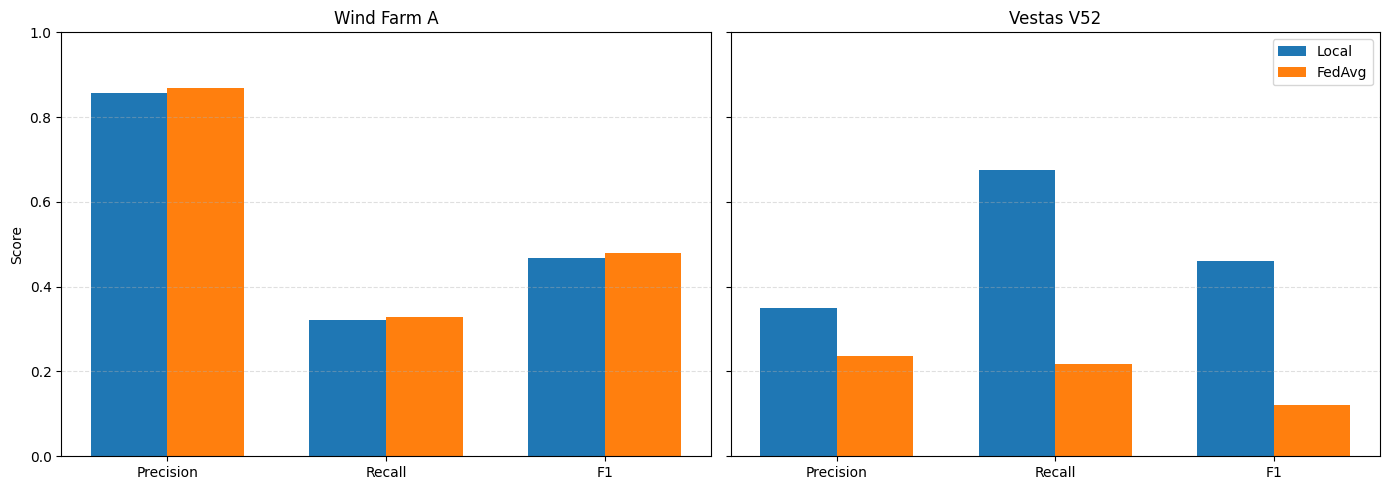

In [25]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["precision", "recall", "f1"]
sites = fl_absolute_results["site"].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, site in zip(axes, sites):
    site_df = fl_absolute_results[fl_absolute_results["site"] == site].reset_index(drop=True)
    x = np.arange(len(metrics))
    width = 0.35

    local_vals = site_df.loc[site_df["model"].str.contains("Local"), metrics].values[0]
    fed_vals = site_df.loc[site_df["model"].str.contains("FedAvg"), metrics].values[0]

    ax.bar(x - width/2, local_vals, width, label="Local")
    ax.bar(x + width/2, fed_vals, width, label="FedAvg")

    ax.set_title(site)
    ax.set_xticks(x)
    ax.set_xticklabels(["Precision", "Recall", "F1"])
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Score")
axes[1].legend()
plt.tight_layout()
plt.savefig("figures/06_federated_absolute_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

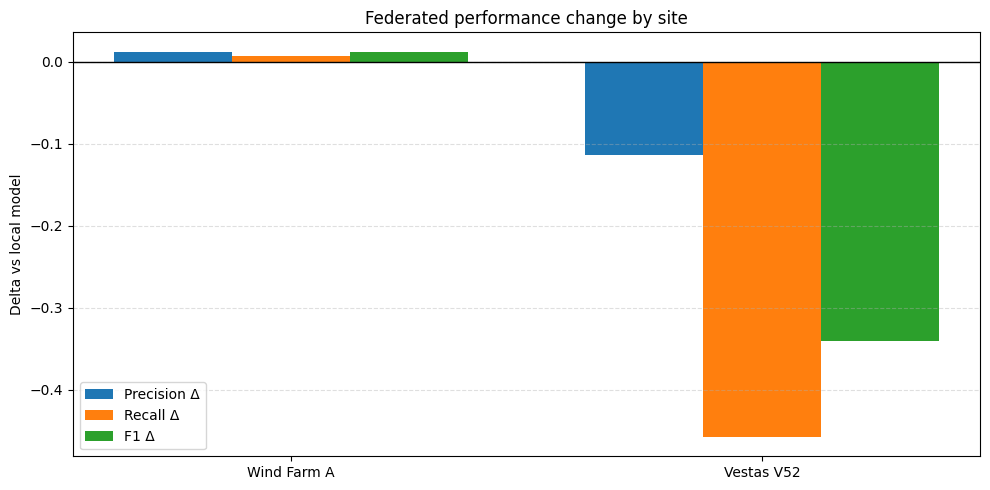

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(fl_delta_results["site"]))
width = 0.25

ax.bar(x - width, fl_delta_results["precision_delta"], width, label="Precision Δ")
ax.bar(x, fl_delta_results["recall_delta"], width, label="Recall Δ")
ax.bar(x + width, fl_delta_results["f1_delta"], width, label="F1 Δ")

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(fl_delta_results["site"])
ax.set_ylabel("Delta vs local model")
ax.set_title("Federated performance change by site")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/06_federated_delta_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
import pandas as pd

federated_summary = pd.DataFrame([
    {
        "site": "Wind Farm A",
        "local_model": "Local Wind Model",
        "federated_model": "FedAvg Global",
        "local_precision": 0.856154,
        "local_recall": 0.322548,
        "local_f1": 0.468567,
        "fed_precision": 0.868724,
        "fed_recall": 0.329280,
        "fed_f1": 0.480481,
        "precision_delta": 0.012570,
        "recall_delta": 0.006732,
        "f1_delta": 0.011914,
        "initial_loss": 0.04734523221850395,
        "final_loss": 0.023239534348249435,
        "loss_improvement_percent": 50.914731517217646
    },
    {
        "site": "Vestas V52",
        "local_model": "Local Vestas Model",
        "federated_model": "FedAvg Global",
        "local_precision": 0.350000,
        "local_recall": 0.674500,
        "local_f1": 0.460900,
        "fed_precision": 0.236029,
        "fed_recall": 0.216757,
        "fed_f1": 0.120895,
        "precision_delta": -0.113971,
        "recall_delta": -0.457743,
        "f1_delta": -0.340005,
        "initial_loss": 0.02338317036628723,
        "final_loss": 0.009978738613426685,
        "loss_improvement_percent": 57.32512547651123
    }
])

federated_summary.to_csv("results/06_federated_summary.csv", index=False)
federated_summary

,site,local_model,federated_model,local_precision,local_recall,local_f1,fed_precision,fed_recall,fed_f1,precision_delta,recall_delta,f1_delta,initial_loss,final_loss,loss_improvement_percent
0,Wind Farm A,Local Wind Model,FedAvg Global,0.856154,0.322548,0.468567,0.868724,0.329280,0.480481,0.012570,0.006732,0.011914,0.047345,0.023240,50.914732
1,Vestas V52,Local Vestas Model,FedAvg Global,0.350000,0.674500,0.460900,0.236029,0.216757,0.120895,-0.113971,-0.457743,-0.340005,0.023383,0.009979,57.325125


In [28]:
from pathlib import Path
import numpy as np
import pandas as pd

Path("results").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

def pick(d, *keys, default=np.nan):
    if not isinstance(d, dict):
        return default
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default

def metric_row(scenario, evaluation_site, source_model, training_regime, metrics, threshold, feature_count):
    return {
        "scenario": scenario,
        "evaluation_site": evaluation_site,
        "source_model": source_model,
        "training_regime": training_regime,
        "feature_count": int(feature_count),
        "threshold": float(threshold) if pd.notna(threshold) else np.nan,
        "precision": pick(metrics, "precision"),
        "recall": pick(metrics, "recall"),
        "f1": pick(metrics, "f1"),
        "pr_auc": pick(metrics, "pr_auc"),
        "true_negatives": pick(metrics, "tn", "true_negatives"),
        "false_positives": pick(metrics, "fp", "false_positives"),
        "false_negatives": pick(metrics, "fn", "false_negatives"),
        "true_positives": pick(metrics, "tp", "true_positives"),
        "predicted_anomalies": pick(metrics, "predicted_anomalies"),
        "actual_anomalies": pick(metrics, "actual_anomalies"),
    }

feature_count = int(X_wind_train.shape[1])

rows = [
    metric_row(
        "Local-Wind → Wind test",
        "Wind",
        "Local-Wind",
        "local",
        local_wind_on_wind,
        wind_local_threshold,
        feature_count
    ),
    metric_row(
        "Local-Vestas → Wind test",
        "Wind",
        "Transfer-from-Vestas",
        "transfer",
        local_vestas_on_wind,
        vestas_local_threshold,
        feature_count
    ),
    metric_row(
        "FedAvg → Wind test",
        "Wind",
        "FedAvg",
        "federated",
        fedavg_on_wind,
        fl_wind_threshold,
        feature_count
    ),
    metric_row(
        "Local-Vestas → Vestas test",
        "Vestas",
        "Local-Vestas",
        "local",
        local_vestas_on_vestas,
        vestas_local_threshold,
        feature_count
    ),
    metric_row(
        "Local-Wind → Vestas test",
        "Vestas",
        "Transfer-from-Wind",
        "transfer",
        local_wind_on_vestas,
        wind_local_threshold,
        feature_count
    ),
    metric_row(
        "FedAvg → Vestas test",
        "Vestas",
        "FedAvg",
        "federated",
        fedavg_on_vestas,
        fl_vestas_threshold,
        feature_count
    ),
]

final_df = pd.DataFrame(rows)

num_cols = [
    "threshold", "precision", "recall", "f1", "pr_auc",
    "true_negatives", "false_positives", "false_negatives", "true_positives",
    "predicted_anomalies", "actual_anomalies"
]
for c in num_cols:
    final_df[c] = pd.to_numeric(final_df[c], errors="coerce")

wind_local_row = final_df.loc[final_df["scenario"] == "Local-Wind → Wind test"].iloc[0]
vestas_local_row = final_df.loc[final_df["scenario"] == "Local-Vestas → Vestas test"].iloc[0]

def site_baseline(row, metric):
    if row["evaluation_site"] == "Wind":
        return wind_local_row[metric]
    return vestas_local_row[metric]

for metric in ["precision", "recall", "f1", "pr_auc"]:
    final_df[f"delta_{metric}_vs_site_local"] = final_df.apply(
        lambda r: r[metric] - site_baseline(r, metric), axis=1
    )

scenario_order = [
    "Local-Wind → Wind test",
    "Local-Vestas → Wind test",
    "FedAvg → Wind test",
    "Local-Vestas → Vestas test",
    "Local-Wind → Vestas test",
    "FedAvg → Vestas test",
]
final_df["scenario"] = pd.Categorical(final_df["scenario"], categories=scenario_order, ordered=True)
final_df = final_df.sort_values("scenario").reset_index(drop=True)

final_df.to_csv("results/06_federated_final_results.csv", index=False)

comparison_df = final_df[[
    "scenario", "evaluation_site", "source_model", "training_regime",
    "feature_count", "threshold", "precision", "recall", "f1", "pr_auc",
    "false_positives", "false_negatives",
    "delta_f1_vs_site_local", "delta_pr_auc_vs_site_local"
]].copy()

for c in [
    "threshold", "precision", "recall", "f1", "pr_auc",
    "delta_f1_vs_site_local", "delta_pr_auc_vs_site_local"
]:
    comparison_df[c] = comparison_df[c].round(6)

comparison_df.to_csv("tables/06_federated_comparison_table.csv", index=False)

print("Saved: results/06_federated_final_results.csv")
print("Saved: tables/06_federated_comparison_table.csv")
comparison_df

Saved: results/06_federated_final_results.csv
Saved: tables/06_federated_comparison_table.csv


,scenario,evaluation_site,source_model,training_regime,feature_count,threshold,precision,recall,f1,pr_auc,false_positives,false_negatives,delta_f1_vs_site_local,delta_pr_auc_vs_site_local
0,Local-Wind → Wind test,Wind,Local-Wind,local,6,0.008305,0.839408,0.053830,0.101172,0.835369,1106,101613,0.000000,0.000000
1,Local-Vestas → Wind test,Wind,Transfer-from-Vestas,transfer,6,0.018869,0.831967,0.492290,0.618564,0.834259,10678,54525,0.517393,-0.001109
2,FedAvg → Wind test,Wind,FedAvg,federated,6,0.046078,0.851978,0.060562,0.113086,0.841544,1130,100890,0.011914,0.006175
3,Local-Vestas → Vestas test,Vestas,Local-Vestas,local,6,0.018869,0.818636,0.822140,0.820384,0.898143,4681,4571,0.000000,0.000000
4,Local-Wind → Vestas test,Vestas,Transfer-from-Wind,transfer,6,0.008305,0.274321,1.000000,0.430536,0.981409,67986,0,-0.389848,0.083266
5,FedAvg → Vestas test,Vestas,FedAvg,federated,6,0.028912,0.704665,0.364397,0.480380,0.661426,3925,16335,-0.340005,-0.236717


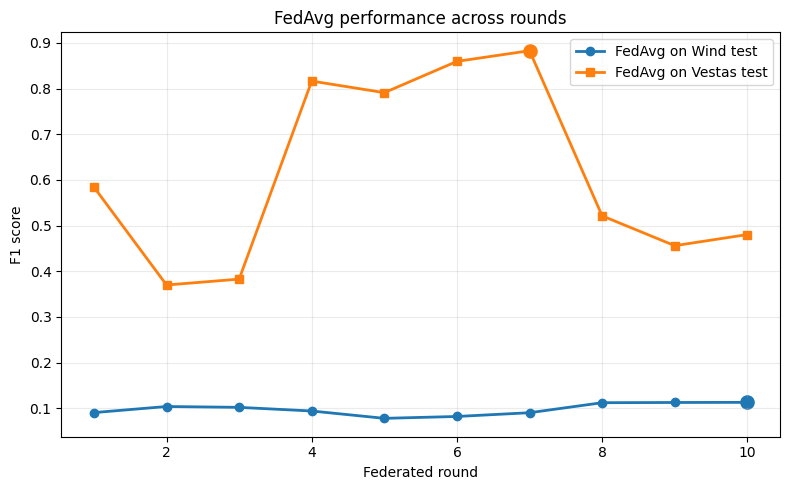

Saved: figures/06_federated_rounds_vs_f1.png


In [29]:
import matplotlib.pyplot as plt

round_metrics_path = Path("results/06_federated_round_metrics.csv")
if not round_metrics_path.exists():
    raise FileNotFoundError(round_metrics_path)

round_df = pd.read_csv(round_metrics_path)
round_df.columns = [c.strip().lower().replace(" ", "_") for c in round_df.columns]

def find_col(df, tokens):
    for c in df.columns:
        if all(t in c for t in tokens):
            return c
    raise KeyError(f"Missing column with tokens: {tokens}")

round_col = find_col(round_df, ["round"])
wind_f1_col = find_col(round_df, ["wind", "f1"])
vestas_f1_col = find_col(round_df, ["vestas", "f1"])

plt.figure(figsize=(8, 5))
plt.plot(round_df[round_col], round_df[wind_f1_col], marker="o", linewidth=2, label="FedAvg on Wind test")
plt.plot(round_df[round_col], round_df[vestas_f1_col], marker="s", linewidth=2, label="FedAvg on Vestas test")

best_wind_i = round_df[wind_f1_col].idxmax()
best_vestas_i = round_df[vestas_f1_col].idxmax()

plt.scatter(round_df.loc[best_wind_i, round_col], round_df.loc[best_wind_i, wind_f1_col], s=90)
plt.scatter(round_df.loc[best_vestas_i, round_col], round_df.loc[best_vestas_i, vestas_f1_col], s=90)

plt.xlabel("Federated round")
plt.ylabel("F1 score")
plt.title("FedAvg performance across rounds")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("figures/06_federated_rounds_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/06_federated_rounds_vs_f1.png")

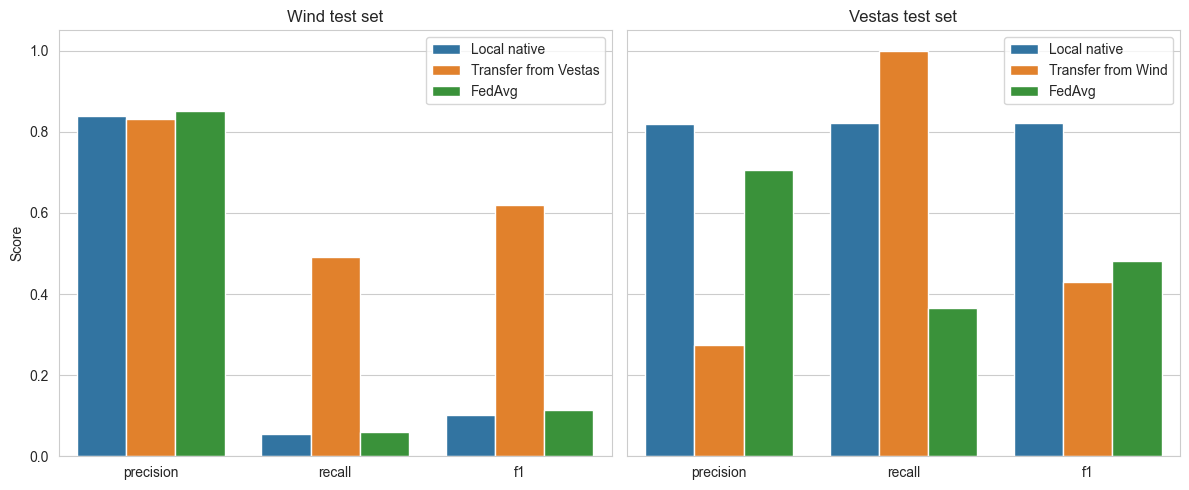

Saved: figures/06_federated_site_comparison.png


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

site_plot_df = pd.DataFrame([
    {
        "evaluation_site": "Wind",
        "approach": "Local native",
        "precision": local_wind_on_wind["precision"],
        "recall": local_wind_on_wind["recall"],
        "f1": local_wind_on_wind["f1"],
    },
    {
        "evaluation_site": "Wind",
        "approach": "Transfer from Vestas",
        "precision": local_vestas_on_wind["precision"],
        "recall": local_vestas_on_wind["recall"],
        "f1": local_vestas_on_wind["f1"],
    },
    {
        "evaluation_site": "Wind",
        "approach": "FedAvg",
        "precision": fedavg_on_wind["precision"],
        "recall": fedavg_on_wind["recall"],
        "f1": fedavg_on_wind["f1"],
    },
    {
        "evaluation_site": "Vestas",
        "approach": "Local native",
        "precision": local_vestas_on_vestas["precision"],
        "recall": local_vestas_on_vestas["recall"],
        "f1": local_vestas_on_vestas["f1"],
    },
    {
        "evaluation_site": "Vestas",
        "approach": "Transfer from Wind",
        "precision": local_wind_on_vestas["precision"],
        "recall": local_wind_on_vestas["recall"],
        "f1": local_wind_on_vestas["f1"],
    },
    {
        "evaluation_site": "Vestas",
        "approach": "FedAvg",
        "precision": fedavg_on_vestas["precision"],
        "recall": fedavg_on_vestas["recall"],
        "f1": fedavg_on_vestas["f1"],
    },
])

melt_df = site_plot_df.melt(
    id_vars=["evaluation_site", "approach"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, site in zip(axes, ["Wind", "Vestas"]):
    subset = melt_df[melt_df["evaluation_site"] == site]
    sns.barplot(data=subset, x="metric", y="score", hue="approach", ax=ax)
    ax.set_title(f"{site} test set")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend(title="", loc="upper right")

plt.tight_layout()
plt.savefig("figures/06_federated_site_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/06_federated_site_comparison.png")

In [31]:
wind_local_f1 = float(local_wind_on_wind["f1"])
vestas_local_f1 = float(local_vestas_on_vestas["f1"])
wind_fed_f1 = float(fedavg_on_wind["f1"])
vestas_fed_f1 = float(fedavg_on_vestas["f1"])

best_wind = final_df[final_df["evaluation_site"] == "Wind"].sort_values("f1", ascending=False).iloc[0]
best_vestas = final_df[final_df["evaluation_site"] == "Vestas"].sort_values("f1", ascending=False).iloc[0]

summary_lines = [
    "Federated Learning Final Comparison",
    "===================================",
    "",
    f"Shared features: {feature_count}",
    f"FL rounds: 10",
    f"Local epochs per round: 3",
    "",
    "Per-site local baselines",
    f"- Local-Wind -> Wind: precision={local_wind_on_wind['precision']:.6f}, recall={local_wind_on_wind['recall']:.6f}, f1={local_wind_on_wind['f1']:.6f}, pr_auc={local_wind_on_wind['pr_auc']:.6f}",
    f"- Local-Vestas -> Vestas: precision={local_vestas_on_vestas['precision']:.6f}, recall={local_vestas_on_vestas['recall']:.6f}, f1={local_vestas_on_vestas['f1']:.6f}, pr_auc={local_vestas_on_vestas['pr_auc']:.6f}",
    "",
    "FedAvg results",
    f"- FedAvg -> Wind: precision={fedavg_on_wind['precision']:.6f}, recall={fedavg_on_wind['recall']:.6f}, f1={fedavg_on_wind['f1']:.6f}, pr_auc={fedavg_on_wind['pr_auc']:.6f}",
    f"- FedAvg -> Vestas: precision={fedavg_on_vestas['precision']:.6f}, recall={fedavg_on_vestas['recall']:.6f}, f1={fedavg_on_vestas['f1']:.6f}, pr_auc={fedavg_on_vestas['pr_auc']:.6f}",
    "",
    "Delta vs site-local baseline",
    f"- Wind site: FedAvg F1 delta = {wind_fed_f1 - wind_local_f1:+.6f}",
    f"- Vestas site: FedAvg F1 delta = {vestas_fed_f1 - vestas_local_f1:+.6f}",
    "",
    "Best model by evaluation site",
    f"- Wind best F1: {best_wind['scenario']} ({best_wind['f1']:.6f})",
    f"- Vestas best F1: {best_vestas['scenario']} ({best_vestas['f1']:.6f})",
    "",
    "Interpretation",
    "FedAvg gives only a small F1 gain over the Wind local baseline.",
    "FedAvg remains substantially below the Vestas local baseline, so collaborative training reduces loss but does not solve site heterogeneity on its own.",
]

with open("results/06_federated_final_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

with open("results/06_federated_final_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("Saved: results/06_federated_final_summary.txt")
print("Saved: results/06_federated_final_summary.md")
print("\n".join(summary_lines))

Saved: results/06_federated_final_summary.txt
Saved: results/06_federated_final_summary.md
Federated Learning Final Comparison

Shared features: 6
FL rounds: 10
Local epochs per round: 3

Per-site local baselines
- Local-Wind -> Wind: precision=0.839408, recall=0.053830, f1=0.101172, pr_auc=0.835369
- Local-Vestas -> Vestas: precision=0.818636, recall=0.822140, f1=0.820384, pr_auc=0.898143

FedAvg results
- FedAvg -> Wind: precision=0.851978, recall=0.060562, f1=0.113086, pr_auc=0.841544
- FedAvg -> Vestas: precision=0.704665, recall=0.364397, f1=0.480380, pr_auc=0.661426

Delta vs site-local baseline
- Wind site: FedAvg F1 delta = +0.011914
- Vestas site: FedAvg F1 delta = -0.340005

Best model by evaluation site
- Wind best F1: Local-Vestas → Wind test (0.618564)
- Vestas best F1: Local-Vestas → Vestas test (0.820384)

Interpretation
FedAvg gives only a small F1 gain over the Wind local baseline.
FedAvg remains substantially below the Vestas local baseline, so collaborative training 

In [32]:
from pathlib import Path

final_outputs = [
    "results/06_federated_final_results.csv",
    "tables/06_federated_comparison_table.csv",
    "figures/06_federated_rounds_vs_f1.png",
    "figures/06_federated_site_comparison.png",
    "results/06_federated_final_summary.txt",
    "results/06_federated_final_summary.md",
]

for p in final_outputs:
    print(f"{p} -> {Path(p).exists()}")

results/06_federated_final_results.csv -> True
tables/06_federated_comparison_table.csv -> True
figures/06_federated_rounds_vs_f1.png -> True
figures/06_federated_site_comparison.png -> True
results/06_federated_final_summary.txt -> True
results/06_federated_final_summary.md -> True
